In [36]:
import stanza
import os
nlp_en = stanza.Pipeline("en", processors="tokenize,pos,lemma")
nlp_fr = stanza.Pipeline("fr", processors="tokenize,pos,lemma")
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import csv
import urllib.request
import numpy as np
import torch
from datasets import load_dataset
from transformers import BertTokenizerFast, BertModel

def download_muse_en_fr(target_path="en_fr_muse.txt"):
    url = "https://dl.fbaipublicfiles.com/arrival/dictionaries/en-fr.txt"
    if not os.path.exists(target_path):
        print(f"Downloading EN-FR dictionary from {url} …")
        urllib.request.urlretrieve(url, target_path)
    return target_path
def load_en_fr_dictionary(path):
    """
    Loads either:
      - MUSE file 'en fr' (space-separated), or
      - TSV 'en\\tfr'
    Returns dict[str, set[str]] of lowercase word forms.
    """
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: 
                continue
            if "\t" in line:
                en, fr = line.split("\t", 1)
            else:
                parts = line.split()
                if len(parts) < 2: 
                    continue
                en, fr = parts[0], parts[1]
            en = en.strip().lower(); fr = fr.strip().lower()
            if en and fr:
                d.setdefault(en, set()).add(fr)
    return d
# ----------------------------
# Config
# ----------------------------
model_name = "bert-base-multilingual-cased"  # 12 layers
tokenizer = BertTokenizerFast.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_attentions=True, output_hidden_states=True)
model.eval() 
WMT_CONFIG = "fr-en"                        # provides {"en","fr"}
WMT_SPLIT = "train"
NUM_PAIRS = 4000
RANDOM_SEED = 42

# Dictionary (EN->FR) via MUSE
EN_FR_DICT_PATH = None  # if None, download MUSE (≈150k entries)
MIN_GOLD_PER_SENT = 1

# Length filter (simple word counts)
MIN_LEN = 8
MAX_EN_LEN = 60


DICT_FILE = download_muse_en_fr()
EN2FR = load_en_fr_dictionary(DICT_FILE)
print(f"Loaded dictionary with {len(EN2FR)} English headwords")

def normalize(nlp, sentence):
    doc = nlp(sentence)
    lemmas = []

    for sent in doc.sentences:
        for word in sent.words:
            if word.lemma:
                lemmas.append(word.lemma.lower())
    return " ".join(lemmas)

print("Loading WMT14 dataset…")
ds = load_dataset("wmt14", WMT_CONFIG, split=WMT_SPLIT)
ds = ds.shuffle(seed=RANDOM_SEED).select(range(min(NUM_PAIRS, len(ds))))
def split_words(s):
    # keep hyphenated words; punctuation returned separately
    return re.findall(r"[A-Za-zÀ-ÖØ-öø-ÿ0-9\-']+|[^\s\w]", s)

def normalize_word(s):
    s = s.lower().replace("’", "'").replace("–", "-").replace("—", "-")
    if s in ["j'", "j’"]:
        s = "j"
    return s

def words_from_raw(raw_tokens):
    is_word = lambda t: re.match(r"[A-Za-zÀ-ÖØ-öø-ÿ0-9\-']+$", t) is not None
    return [normalize_word(t) for t in raw_tokens if is_word(t)]
def filter_length(en_text, fr_text, min_len=3, max_len=60): # adjust the length of sentences 
    en_n = len(words_from_raw(split_words(en_text)))
    fr_n = len(words_from_raw(split_words(fr_text)))
    return (min_len <= en_n <= max_len) and (min_len <= fr_n <= max_len)

    

2026-03-31 19:46:02 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-31 19:46:02 INFO: Downloaded file to /u/xay7te/.cache/stanza/1.11.0/resources/resources.json
2026-03-31 19:46:02 WARNING: Language en package default expects mwt, which has been added
2026-03-31 19:46:02 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |

2026-03-31 19:46:02 INFO: Using device: cuda
2026-03-31 19:46:02 INFO: Loading: tokenize
2026-03-31 19:46:02 INFO: Loading: mwt
2026-03-31 19:46:02 INFO: Loading: pos
2026-03-31 19:46:03 INFO: Loading: lemma
2026-03-31 19:46:04 INFO: Done loading processors!
2026-03-31 19:46:04 INFO: Checking for updates to resou

Loaded dictionary with 94681 English headwords
Loading WMT14 dataset…


In [38]:
from matplotlib import pyplot as plt
error = []
counter_sentence = 0
for ex in ds:
    en_text = normalize(nlp_en, ex["translation"]["en"])
    fr_text = normalize(nlp_fr,ex["translation"]["fr"])
    if not filter_length(en_text, fr_text, min_len=MIN_LEN, max_len=MAX_EN_LEN):
        continue
    if counter_sentence>1000: 
        break
# computing attention across the layers 

    en_words_raw = split_words(en_text)
    fr_words_raw = split_words(fr_text)
    
    encoding = tokenizer(
        en_words_raw,
        fr_words_raw,
        is_split_into_words=True,   # crucial for word_ids()
        add_special_tokens=True,
        return_tensors="pt",
        return_attention_mask=True,
        return_token_type_ids=True
    )
    input_ids      = encoding["input_ids"]       # (1, L)
    attn_mask      = encoding["attention_mask"]  # (1, L)
    token_type_ids = encoding["token_type_ids"]  # (1, L) 0=EN segment, 1=FR segment
    if len(input_ids[0])> 510: 
        continue
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attn_mask,
            token_type_ids=token_type_ids,
            output_attentions=True,
            output_hidden_states=True,
            return_dict=True,
        )
    
    attentions    = outputs.attentions           # tuple len = num_layers; each (1, heads, L, L)
    hidden_states = outputs.hidden_states        # tuple len = num_layers+1; 0=embeddings, 1..12 layers
    num_layers    = len(attentions)
    
    seq_ids  = encoding.sequence_ids(0)  # list length L; 0 for EN, 1 for FR, None specials
    word_ids = encoding.word_ids(0)      # list length L; per-segment word index, None for specials
    # finding the index of en and translated words 
    en_tok_idx, fr_tok_idx = [], []
    en_tok2word, fr_tok2word = [], []
    
    for i, (sid, wid) in enumerate(zip(seq_ids, word_ids)):
        if sid == 0 and wid is not None:   # EN tokens (exclude specials/punct)
            en_tok_idx.append(i)
            en_tok2word.append(wid)
        elif sid == 1 and wid is not None: # FR tokens
            fr_tok_idx.append(i)
            fr_tok2word.append(wid)

    # translating token to words 
    src = tokenizer(en_text, return_tensors="pt", add_special_tokens=False)
    tgt = tokenizer(text_target=fr_text, return_tensors="pt", add_special_tokens=False)
    fr_dict = {} 
    en_dict = {} 
    
    fr_dict['token_ids'] = np.asarray(input_ids[0][fr_tok_idx])
    fr_dict['token_idx'] = fr_tok_idx
    en_dict['token_idx'] = en_tok_idx
    en_dict['token_ids'] = np.asarray(input_ids[0][en_tok_idx])
    fr_dict['nlp'] = nlp_fr 
    en_dict['nlp'] = nlp_en 
    en_dict['text'] = en_text 
    fr_dict['text'] = fr_text 
    en_dict['word_ids'] = np.asarray(en_tok2word) 
    fr_dict['word_ids'] = np.asarray(fr_tok2word)
    dicts = [en_dict,fr_dict]
    
    def get_words(tokenizer,tdict): 
        words = [] 
        tokens_ids = tdict['token_ids'] 
        nlp = tdict['nlp']
        word_ids = tdict['word_ids']
       
        for i in range(max(word_ids)): 
            
            idx_ids = np.where(word_ids == i)[0]
            # print(len(word_ids),i,idx_ids,len(tokens_ids))
            words.append(normalize(nlp,tokenizer.decode(tokens_ids[idx_ids])))
        return words
        
    for dicta in dicts: 
        dicta['words'] = get_words(tokenizer,dicta)
        
    # extracting attention weights for words 
    word_attns = [] 
    error_across_depth =[] 
    for hiddenst in hidden_states:
        n = len(dicts[0]['words'])+1
        m = len(dicts[1]['words']) +1 
        watt = torch.zeros(n,m)
        count = torch.zeros(n,m)
        for i in range(len(dicts[0]['word_ids'])):
            for j in range(len(dicts[1]['word_ids'])): 
                idx1 = dicts[0]['word_ids'][i]
                idx2 = dicts[1]['word_ids'][j]
                count[idx1,idx2] +=1 
                watt[idx1,idx2] += torch.norm(hiddenst[0,dicts[0]['token_idx'][i],:]-hiddenst[0,dicts[1]['token_idx'][j],:])
        watt = watt/count 
       
    
          # matching translated words 
        keys = [] 
        values = [] 
        for i in range(len(dicts[0]['words'])): 
            word = dicts[0]['words'][i]
            trans = EN2FR.get(word)
            if trans: 
                match = trans & set(dicts[1]['words'])
                match = list(match) 
                if len(match)>0: 
                    keys.append(i) 
                    values.append(dicts[1]['words'].index(match[0]))
        if len(keys)<MIN_LEN: 
            continue
        # croping attention for pairs of translated words (some words are removed since the dictionary can not pair them)
        
        n = len(keys)
        attc = torch.zeros(n,n)
        for i in range(n): 
            for j in range(n): 
                attc[i,j] = watt[keys[i],values[j]]
        import ot
        M = attc.detach().cpu().numpy()
        a = np.ones(M.shape[0])
        b = np.ones(M.shape[0])
        # Solve the OT problem
        sol = ot.solve(M)
        
        # get the OT plan
        P = sol.plan
        P[P>0.0001] = 1 
        diagP = np.diag(P)
        error_across_depth.append(np.sum(diagP<0.99).item()/len(diagP))
    if len(error_across_depth)<3: 
        continue
    counter_sentence +=1 
    if counter_sentence % 100 == 0: 
        print(counter_sentence)
    error.append(error_across_depth)

100
200
300
400
500
600
700
800
900
1000


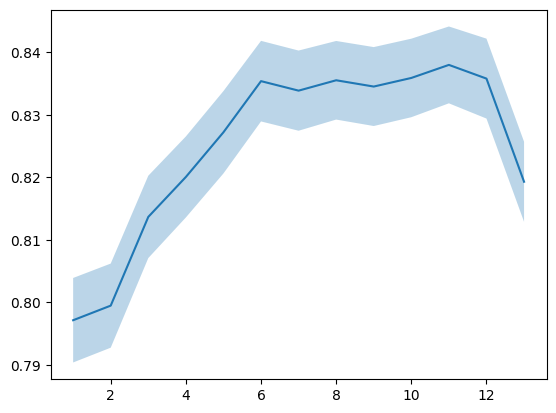

<Figure size 640x480 with 0 Axes>

In [43]:
results = 1-np.asarray(error).T

x = np.asarray(range(results.shape[0]))+1
mean = np.mean(results, axis=1)      # shape (k,)
std = np.std(results, axis=1, ddof=1)

n = results.shape[1]
se = std / np.sqrt(n)          # standard error
z = 1.282                      # 80% two-sided normal CI

lower = mean - z * se
upper = mean + z * se

plt.plot(x, mean, label="Mean")
plt.fill_between(x, lower, upper, alpha=0.3, label="90% CI")
# plt.legend()
plt.show()
plt.savefig('OT-embeddings.pdf',format='pdf')